In [11]:
import pandas as pd


The dataset was cleaned and prepared before analysis to ensure accurate results.

In [12]:
orders=pd.read_csv("orders_cleaned.csv")
order_items=pd.read_csv("order_items_cleaned.csv")
payment=pd.read_csv("order_payment_cleaned.csv")
sellers=pd.read_csv("sellers_cleaned.csv")
products=pd.read_csv("products_cleaned.csv")
review=pd.read_csv("order_review_cleaned.csv")
category=pd.read_csv("category_name_cleaned.csv")
geolocation=pd.read_csv("geolocation_cleaned.csv")
customers=pd.read_csv("customers_cleaned.csv")


Monthly revenue shows the total sales in each month.

In [13]:
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders["month"] = orders["order_purchase_timestamp"].dt.month
orders_items_merged = pd.merge(orders, order_items, on="order_id", how="inner")
monthly_revenue = orders_items_merged.groupby("month")["price"].sum()
print(monthly_revenue) 



month
1     1036357.47
2     1059105.98
3     1312555.10
4     1314203.77
5     1466703.94
6     1277515.34
7     1349090.99
8     1393276.34
9      607355.64
10     689188.95
11     987648.07
12     726044.09
Name: price, dtype: float64


graph which shows the monthly revenue

<function matplotlib.pyplot.show(close=None, block=None)>

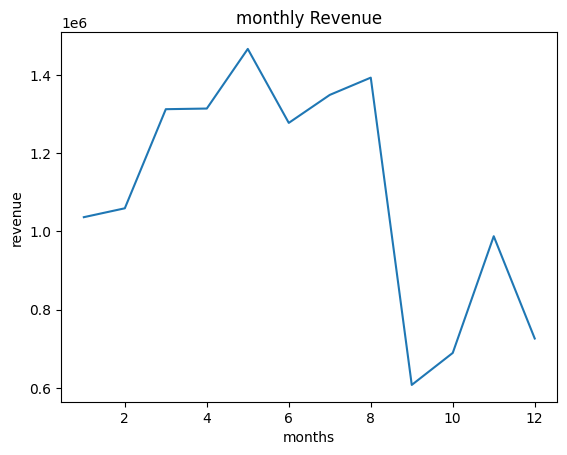

In [14]:
import matplotlib.pyplot as plt
monthly_revenue.plot()
plt.title("monthly Revenue")
plt.xlabel("months")
plt.ylabel("revenue")
plt.show

This shows the top 5 most sold products.

In [15]:
print(order_items["product_id"].value_counts().head(5))

product_id
aca2eb7d00ea1a7b8ebd4e68314663af    527
99a4788cb24856965c36a24e339b6058    488
422879e10f46682990de24d770e7f83d    484
389d119b48cf3043d311335e499d9c6b    392
368c6c730842d78016ad823897a372db    388
Name: count, dtype: int64


Top 5 states which produce heighest revenue.

In [16]:
order_merged = pd.merge(order_items, orders, on="order_id", how="left")
final_merge = pd.merge(order_merged, customers, on="customer_id", how='left')
final_merge["revenue"] = final_merge["price"] + final_merge["freight_value"]
top_states = final_merge.groupby("customer_state")["revenue"].sum().sort_values(ascending=False).head(5)
print(f"The top 5 states which produce heighest revenue are:\n{top_states}")

The top 5 states which produce heighest revenue are:
customer_state
SP    5767792.05
RJ    2055589.53
MG    1818644.05
RS     860724.74
PR     781708.80
Name: revenue, dtype: float64


This shows how many orders are delivered, shipped, and cancelled.

In [17]:
status=(orders["order_status"].value_counts())
print(status)

order_status
delivered    96455
canceled         6
Name: count, dtype: int64


Graph which shows the order status.

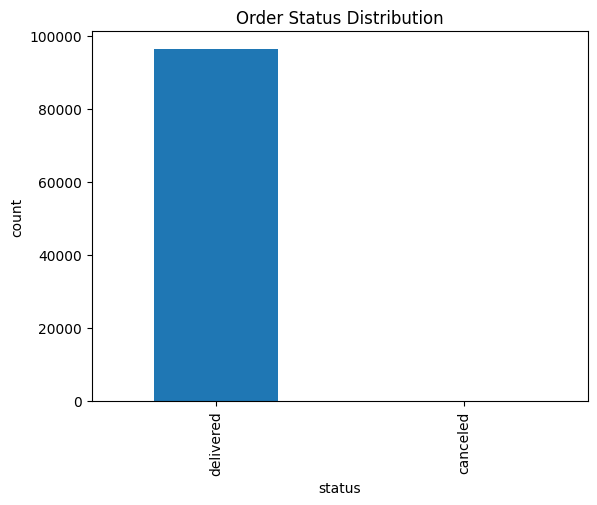

In [18]:
import matplotlib.pyplot as plt
status.plot(kind="bar")
plt.title("Order Status Distribution")
plt.xlabel("status")
plt.ylabel("count")
plt.show()

This shows which payment method is used the most by customers.

In [19]:
payment=(payment["payment_type"].value_counts())
print(payment)

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


graph which shows the payment distribution type

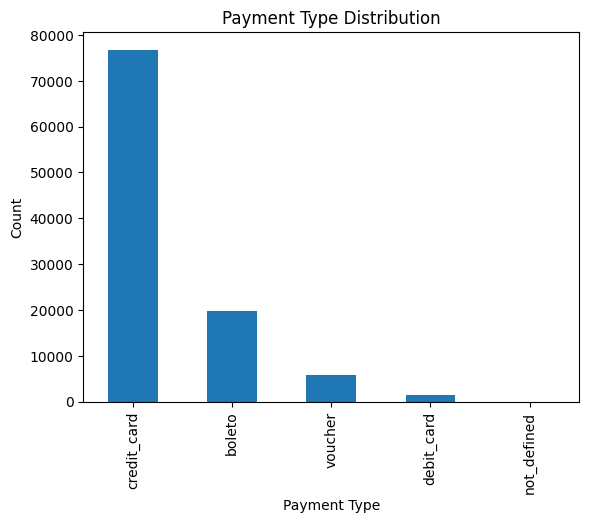

In [20]:

payment.plot(kind='bar')
plt.title("Payment Type Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Count")
plt.show()

This shows the average amount spent per order.

In [21]:
merged = pd.merge(order_items, orders, on="order_id", how="left")
revenue = merged["price"] + merged["freight_value"]
average_revenue = revenue.mean()
print(f"The average revenue of all the orders is:\n {average_revenue}")

The average revenue of all the orders is:
 140.6440589436307


The order purchase time was converted into date format for better analysis.

In [22]:
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])

These are the top 5 customers who ordered the most.

In [23]:
merged=pd.merge(orders,customers,on="customer_id",how="left")
group=merged.groupby("customer_id")["order_id"].count().sort_values(ascending=False).head(5)
print(f"The top 5 customers by order are : \n{group}")



The top 5 customers by order are : 
customer_id
00012a2ce6f8dcda20d059ce98491703    1
000161a058600d5901f007fab4c27140    1
0001fd6190edaaf884bcaf3d49edf079    1
0002414f95344307404f0ace7a26f1d5    1
000379cdec625522490c315e70c7a9fb    1
Name: order_id, dtype: int64


This shows the month with the highest revenue.

In [24]:
heighest_revenue=(monthly_revenue.idxmax())
print(f"The heighest revenue month is = {heighest_revenue} , and it is due to high discount")
print(monthly_revenue.max())


The heighest revenue month is = 5 , and it is due to high discount
1466703.94


This displays the first few rows of the data.

In [25]:
print(products.head())
print(order_items.head())
print(payment.head())

                         product_id  product_category_name  \
0  1e9e8ef04dbcff4541ed26657ea517e5             perfumaria   
1  3aa071139cb16b67ca9e5dea641aaa2f                  artes   
2  96bd76ec8810374ed1b65e291975717f          esporte_lazer   
3  cef67bcfe19066a932b7673e239eb23d                  bebes   
4  9dc1a7de274444849c219cff195d0b71  utilidades_domesticas   

   product_name_lenght  product_description_lenght  product_photos_qty  \
0                 40.0                       287.0                 1.0   
1                 44.0                       276.0                 1.0   
2                 46.0                       250.0                 1.0   
3                 27.0                       261.0                 1.0   
4                 37.0                       402.0                 4.0   

   product_weight_g  product_length_cm  product_height_cm  product_width_cm  
0             225.0               16.0               10.0              14.0  
1            1000.0       

This shows the top 5 customers who generated the highest revenue.

In [26]:
merged=pd.merge(order_items,orders,on="order_id",how="left")
final=pd.merge(merged,customers,on="customer_id",how="left")
final["revenue"]=final["price"]+final["freight_value"]
top_customers=final.groupby(["customer_unique_id","customer_city","customer_state"])["revenue"].sum()
top_customers=top_customers.sort_values(ascending=False).head()
print(f"The top 5 customers who make more revenue are:\n{top_customers}")


The top 5 customers who make more revenue are:
customer_unique_id                customer_city   customer_state
0a0a92112bd4c708ca5fde585afaa872  rio de janeiro  RJ                13664.08
da122df9eeddfedc1dc1f5349a1a690c  araruama        RJ                 7571.63
763c8b1c9c68a0229c42c9fc6f662b93  vila velha      ES                 7274.88
dc4802a71eae9be1dd28f5d788ceb526  campo grande    MS                 6929.31
459bef486812aa25204be022145caa62  vitoria         ES                 6922.21
Name: revenue, dtype: float64


graph which shows the top 5 customers who generate the highest revenue

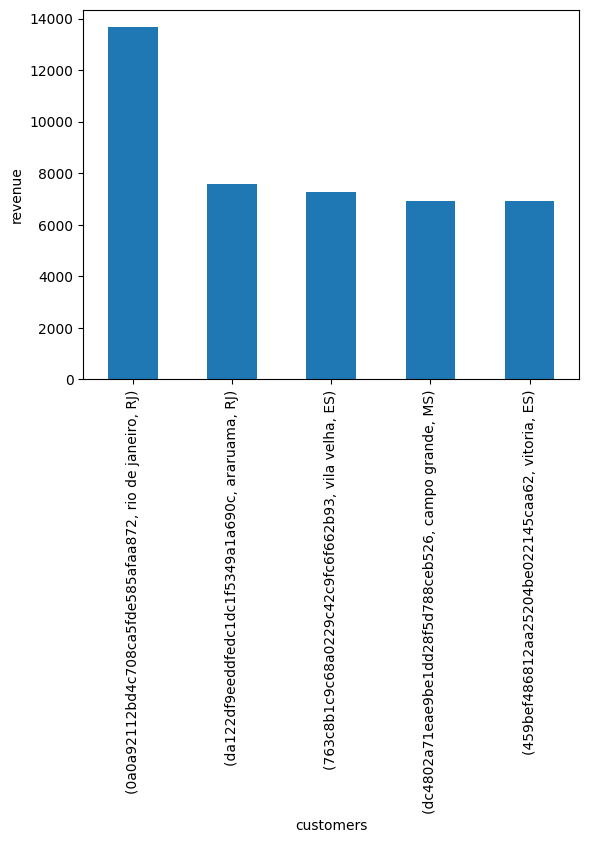

In [27]:
import matplotlib.pyplot as plt
top_customers.plot(kind="bar")
plt.xlabel("customers")
plt.ylabel("revenue")
plt.show()

This shows the average time taken to deliver the orders.

In [28]:
orders["order_purchase_timestamp"]=pd.to_datetime(orders["order_purchase_timestamp"])
orders.columns
orders["order_delivered_carrier_date"]=pd.to_datetime(orders["order_delivered_carrier_date"])
time=orders["order_delivered_carrier_date"]-orders["order_purchase_timestamp"]
print(time.mean())

3 days 05:27:37.866578


Tables were merged to get complete data and calculate revenue.

In [29]:
merged=pd.merge(order_items,orders,on="order_id",how="left")
merged1=pd.merge(merged,customers,on="customer_id",how="left")
revenue=merged1["price"]+merged1["freight_value"]


This shows the top 5 most sold product categories.

In [30]:
merged=pd.merge(order_items,products,on="product_id",how="left")
top_categories=merged["product_category_name"].value_counts().head()
print(f"The top 5 most selling categories are :\n{top_categories}")

The top 5 most selling categories are :
product_category_name
cama_mesa_banho           11115
beleza_saude               9670
esporte_lazer              8641
moveis_decoracao           8334
informatica_acessorios     7827
Name: count, dtype: int64


Graph which shows the top selling categories.

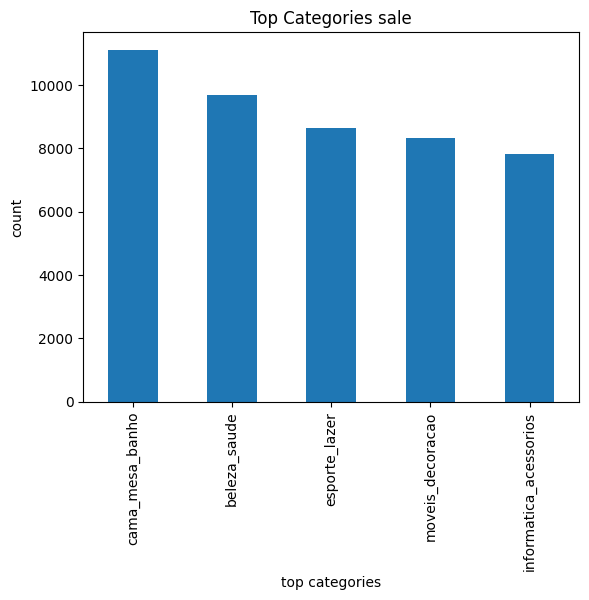

In [31]:
import matplotlib.pyplot as plt
top_categories.plot(kind="bar")
plt.title("Top Categories sale")
plt.xlabel("top categories")
plt.ylabel("count")
plt.show()

In [32]:
len(orders)

96461

This shows the total amount earned from all products.

In [33]:
order_items["price"].sum()

np.float64(13591643.7)

This shows the total number of unique orders.

In [34]:
unique_orders=orders["order_id"].nunique()
print(unique_orders)

96461


This displays the first few rows of the order items table.

In [35]:
print(order_items.head())

                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   
3  00024acbcdf0a6daa1e931b038114c75              1   
4  00042b26cf59d7ce69dfabb4e55b4fd9              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   
3  7634da152a4610f1595efa32f14722fc  9d7a1d34a5052409006425275ba1c2b4   
4  ac6c3623068f30de03045865e4e10089  df560393f3a51e74553ab94004ba5c87   

   shipping_limit_date   price  freight_value  
0  2017-09-19 09:45:35   58.90          13.29  
1  2017-05-03 11:05:13  239.90          19.93  
2  2018-01-18 14:48:30  199.00          17.87  
3  2018-08-15 10:10:18   12.99          12.7

This shows the total revenue including product price and delivery charges.

In [36]:
total_revenue=(order_items["price"]+order_items["freight_value"]).sum()
print(total_revenue)

15843553.24


This shows how many items(products) are present in the dataset.

In [37]:
len(order_items)

112650